<a href="https://colab.research.google.com/github/Tejaswibatchala/Tejaswibatchala/blob/main/Used_cars_messy_csvData_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv("/content/used_cars_messy.csv")
df

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,2581,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,224,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0,67.04,5.0,435000.0
2,1803,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0
3,2728,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0,NaN,8.0,925000.0
4,14160,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0,140.00,7.0,1175000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,6581,Maruti Ertiga,Maruti,Ertiga,7,127731,Dealer,Diesel,Manual,20.77,1248.0,88.80,7.0,665000.0
15657,17029,Volkswagen Vento,Volkswagen,Vento,11,59000,Dealer,Petrol,Manual,16.09,NaN,103.20,5.0,249000.0
15658,6839,Maruti Wagon R,Maruti,Wagon R,7,20000,Individual,Petrol,Manual,20.51,998.0,67.04,5.0,250000.0
15659,1104,Hyundai i20,Hyundai,i20,2,15000,Dealer,Petrol,Manual,18.6,1197.0,81.86,5.0,620000.0


In [8]:
df.shape

(15661, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15661 entries, 0 to 15660
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15661 non-null  int64  
 1   car_name           15661 non-null  object 
 2   brand              15661 non-null  object 
 3   model              15661 non-null  object 
 4   vehicle_age        15661 non-null  int64  
 5   km_driven          15661 non-null  object 
 6   seller_type        15661 non-null  object 
 7   fuel_type          15661 non-null  object 
 8   transmission_type  15661 non-null  object 
 9   mileage            14376 non-null  object 
 10  engine             13792 non-null  float64
 11  max_power          14862 non-null  float64
 12  seats              15218 non-null  float64
 13  selling_price      15503 non-null  float64
dtypes: float64(4), int64(2), object(8)
memory usage: 1.7+ MB


In [6]:
(df.isnull().sum()*100)/len(df)

,0
Unnamed: 0,0.000000
car_name,0.000000
brand,0.000000
model,0.000000
vehicle_age,0.000000
km_driven,0.000000
seller_type,0.000000
fuel_type,0.000000
transmission_type,0.000000
mileage,8.205095


In [9]:
df.duplicated().sum()

np.int64(169)

In [10]:
df[df.duplicated(keep=False)]

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
161,4246,Tata Safari,Tata,Safari,9,100000,Individual,Diesel,Manual,11.57,2179.0,138.10,7.0,260000.0
174,4763,Skoda Rapid,Skoda,Rapid,6,55300,Dealer,Diesel,Automatic,21.66,1498.0,103.52,5.0,650000.0
202,14596,Maruti Alto,Maruti,Alto,2,25000,Individual,Petrol,Manual,24.7,796.0,47.30,5.0,300000.0
285,7096,Hyundai i10,Hyundai,i10,11,52000,Dealer,Petrol,Manual,NaN,1197.0,78.90,5.0,280000.0
293,646,Honda Amaze,Honda,Amaze,3,50000,Individual,Petrol,Manual,17.8,1198.0,86.70,5.0,550000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15437,6814,Hyundai i10,Hyundai,i10,7,89800,Dealer,Petrol,Manual,20.36,1197.0,78.90,5.0,275000.0
15438,17972,Mahindra XUV500,Mahindra,XUV500,8,95000,Dealer,Diesel,Manual,15.1,2179.0,140.00,7.0,825000.0
15514,4543,Toyota Innova,Toyota,Innova,12,200000,Individual,Diesel,Manual,12.8,2494.0,102.00,7.0,480000.0
15524,18228,Mahindra XUV500,Mahindra,XUV500,9,80000,Individual,Diesel,Manual,15.1,2179.0,140.00,7.0,875000.0


In [11]:
cat_cols=["brand","seller_type","fuel_type","transmission_type"]
for cat in cat_cols:
  unique_vals=df[cat].unique()
  print(f"\n{cat} ({len(unique_vals)} unique_values)")
  print(sorted(unique_vals))


brand (80 unique_values)
[' Audi', ' Audi ', ' BMW', ' BMW ', ' Datsun', ' Datsun ', ' Ferrari ', ' Ford', ' Ford ', ' Honda', ' Honda ', ' Hyundai', ' Hyundai ', ' ISUZU ', ' Land Rover', ' MG ', ' Mahindra', ' Mahindra ', ' Maruti', ' Maruti ', ' Mercedes-AMG ', ' Mercedes-Benz ', ' Mini ', ' Nissan ', ' Porsche', ' Renault', ' Renault ', ' Skoda', ' Skoda ', ' Tata', ' Tata ', ' Toyota', ' Toyota ', ' Volkswagen', ' Volkswagen ', 'Audi', 'Audi ', 'BMW', 'BMW ', 'Bentley', 'Datsun', 'Datsun ', 'Force', 'Ford', 'Ford ', 'Honda', 'Honda ', 'Hyundai', 'Hyundai ', 'ISUZU', 'Isuzu', 'Jaguar', 'Jeep', 'Kia', 'Land Rover', 'Lexus', 'MG', 'Mahindra', 'Mahindra ', 'Maruti', 'Maruti ', 'Maserati', 'Mercedes-Benz', 'Mercedes-Benz ', 'Mini', 'Nissan', 'Porsche', 'Renault', 'Renault ', 'Rolls-Royce', 'Skoda', 'Skoda ', 'Tata', 'Tata ', 'Toyota', 'Toyota ', 'Volkswagen', 'Volkswagen ', 'Volvo', 'Volvo ']

seller_type (9 unique_values)
['DEALER', 'Dealer', 'Delaer', 'Individual', 'Individuall', 'I

In [12]:
df['km_driven'].dtype

dtype('O')

In [13]:
df['km_driven'].head(100)

,km_driven
0,67647
1,52000
2,48959
3,82000
4,34000
...,...
95,68000
96,98000
97,53892
98,20001


In [14]:
df[df['km_driven']==67647]

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price


In [15]:
df['km_driven'].sample(100).tolist()

['49000',
 '56000',
 '60000',
 '39000',
 '10000',
 '5000',
 '35000',
 '80000',
 '36000',
 '53000',
 '84000',
 '5000',
 '19000',
 '9000',
 '51000',
 '29000',
 '70000',
 '62500',
 '2700',
 '58000',
 '50000',
 '56000',
 '87000',
 '3192',
 '78000',
 '67000',
 '63165',
 '42000',
 '26000',
 '77000',
 '154000',
 '1750',
 '60000',
 '44000',
 '9000',
 '63000',
 '3500',
 '32000',
 '8836',
 '78000',
 '40000',
 '25000',
 '33072',
 '100000',
 '59311',
 '35000',
 '84768',
 '80000',
 '70000',
 '35000',
 '103000',
 '27000',
 '26844',
 '30000',
 '35000',
 '148712',
 '60000',
 '51000',
 '30202',
 '41000',
 '59200',
 '70000',
 '170000',
 '51916',
 '50000',
 '34633',
 '43715',
 '84000',
 '68000',
 '10000',
 '120000',
 '50000',
 '74352',
 '17000',
 '68000',
 '70000',
 '72000',
 '70000',
 '64000',
 '5000',
 '29000',
 '58455',
 '32500',
 '30000',
 '12000',
 '65369',
 '50000',
 '30000',
 '72000 km',
 '26600',
 '95000',
 '38000 kms',
 '100000',
 '50000',
 '100000',
 '120000',
 '26000',
 '36000',
 '49000',
 '12

In [16]:
df['mileage'].dtype

dtype('O')

In [17]:
df['mileage'].head(100)

,mileage
0,19.87
1,33.54
2,NaN
3,15.4
4,16.0
...,...
95,13.0
96,22.1
97,24.3
98,13.5


In [18]:
df['mileage'].sample(200).tolist()

['18.6',
 nan,
 '21.79',
 '20.14',
 '19.3',
 '23.4',
 '14.3',
 '28.09',
 '20.36',
 '22.32',
 '18.9',
 nan,
 '20.89',
 '17.8',
 nan,
 '16.46',
 '19.3',
 '12.99',
 '25.5',
 '25.2',
 '23.0',
 '18.9',
 '18.5',
 '13.0',
 nan,
 '17.3',
 '19.16',
 '23.1',
 '20.73',
 '26.59',
 '22.0',
 '22.1',
 '22.77',
 '22.0',
 '26.6',
 '10.8',
 '17.0',
 '24.3',
 '15.4',
 '21.14',
 nan,
 '22.0',
 '19.44',
 '18.7',
 '19.87',
 nan,
 '20.73',
 '19.7',
 '25.32',
 '15.0',
 '21.63',
 '12.8',
 '28.4',
 '18.5',
 '17.21',
 '20.35',
 '22.32',
 '23.95',
 '17.0',
 '22.32',
 '22.7',
 '17.8',
 '16.02',
 nan,
 '25.8',
 '17.01',
 '19.01',
 '21.21',
 '12.7',
 '18.9',
 nan,
 '22.48',
 '18.0',
 nan,
 '21.4',
 '22.07',
 '20.0',
 '20.34',
 '23.4',
 '18.6',
 '20.73',
 '22.15',
 '22.0',
 '13.68',
 '14.3',
 '23.01',
 '19.12',
 '17.4',
 '21.21',
 '20.5',
 '21.79',
 '20.0',
 '17.7',
 '24.3',
 '22.0',
 nan,
 nan,
 '26.0',
 '18.7',
 '17.21',
 '25.8',
 '17.0',
 '20.77',
 '20.0',
 nan,
 '21.21',
 '19.7',
 nan,
 '19.5',
 '17.7',
 '20.51',

In [19]:
pd.set_option('display.float_format','{:.4f}'.format)

In [20]:
df['selling_price'].describe()

,selling_price
count,15503.0000
mean,1032763.7793
std,16073797.4950
min,500.0000
25%,385000.0000
50%,555000.0000
75%,825000.0000
max,999999999.0000


In [21]:
#drop the useless columns

In [22]:
df.columns

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')

In [23]:
print(df.columns.tolist())

['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']


In [25]:
df= df.drop(columns=['Unnamed:0'])
print(df.columns)

Index(['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats', 'selling_price'],
      dtype='object')


In [4]:
print(df.columns.tolist())

['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']


In [26]:
#fix the brand names

In [27]:
df.describe()
df


,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0000,83.8000,5.0000,575000.0000
1,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0000,67.0400,5.0000,435000.0000
2,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0000,117.6000,5.0000,875000.0000
3,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0000,NaN,8.0000,925000.0000
4,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0000,140.0000,7.0000,1175000.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,Maruti Ertiga,Maruti,Ertiga,7,127731,Dealer,Diesel,Manual,20.77,1248.0000,88.8000,7.0000,665000.0000
15657,Volkswagen Vento,Volkswagen,Vento,11,59000,Dealer,Petrol,Manual,16.09,NaN,103.2000,5.0000,249000.0000
15658,Maruti Wagon R,Maruti,Wagon R,7,20000,Individual,Petrol,Manual,20.51,998.0000,67.0400,5.0000,250000.0000
15659,Hyundai i20,Hyundai,i20,2,15000,Dealer,Petrol,Manual,18.6,1197.0000,81.8600,5.0000,620000.0000


In [50]:
print(f"Unique values before cleaning{df['brand'].nunique()}")
df['brand']=df['brand'].str.strip()
print (f"Unique values after cleaning {df['brand'].nunique()}")
df['brand'].value_counts().head(10)

Unique values before cleaning32
Unique values after cleaning 32


,count
brand,
Maruti,5020
Hyundai,3002
Honda,1495
Mahindra,1015
Toyota,801
Ford,792
Volkswagen,627
Renault,539
BMW,440


In [ ]:
#fix fuel type

In [34]:
print(f"Unique valuesbefore cleaning{df['fuel_type'].nunique()}")
df['fuel_type']=df['fuel_type'].str.strip().str.title()
print(f"Unique values after cleaning{df['fuel_type'].nunique()}")
df['fuel_type'].value_counts().head(10)

Unique valuesbefore cleaning14
Unique values after cleaning5


,count
fuel_type,
Petrol,7765
Diesel,7544
Cng,302
Lpg,46
Electric,4


# fix the  seller type

In [51]:
print(f"Unique values before cleaning{df['seller_type'].nunique()}")
df['seller_type']=df['seller_type'].str.strip().str.title()
print(f"Unique values after cleaning{df['seller_type'].nunique()}")
# create dictionary
#fix remaining typos with a mapping
typo_map={'Individul': 'Individual',
          'Individuall': 'Individual',
          'Delaer':'Dealer',
          'Trustmark Delaer':'Trustmark Dealer',
}

df['seller_type']=df['seller_type'].replace(typo_map)
print(f"final unique values after cleaning{df['seller_type'].nunique()}")
print(df['seller_type'].value_counts())

Unique values before cleaning3
Unique values after cleaning3
final unique values after cleaning3
seller_type
Dealer              9592
Individual          5738
Trustmark Dealer     173
Name: count, dtype: int64


# fix numeric columns with string issues

In [40]:
df['km_driven'].sample(100).tolist()
df['km_driven']=df['km_driven'].astype(str).str.replace(",","")
df['km_driven']=df['km_driven'].astype(str).str.replace("kms","")
df['km_driven']=df['km_driven'].astype(str).str.replace("km","")
df['km_driven']=df['km_driven'].str.strip()
df['km_driven']=pd.to_numeric(df['km_driven'],errors='coerce')
df['km_driven'].sample(100)


,km_driven
5554,40000
6480,35000
10274,151768
14946,24812
15295,38000
...,...
8952,175000
10297,59000
9275,47000
3774,10000


# handling missing values

In [41]:
df.loc[3,"km_driven"]
df.isnull().sum()

,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,1285
engine,1869


In [52]:
before=len(df)
df=df.dropna(subset=['selling_price'])
after=len(df)
print(f"Drop{before-after} rows where selling_price was missing")
print(f"remaining rows{after}")

Drop0 rows where selling_price was missing
remaining rows15503


fix for mileage

In [53]:
# First, clean and convert 'mileage' to numeric
df['mileage'] = df['mileage'].astype(str).str.replace("kmpl", "", regex=False)
df['mileage'] = df['mileage'].str.strip()
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce') # 'coerce' will turn unparseable values into NaN

# Now, iterate and fill missing values with median
for col in ["engine","mileage","max_power"]:
  median_val=df[col].median()
  df[col]=df[col].fillna(median_val)
  print(f"filled {col} missing values with median: {median_val}")

filled engine missing values with median: 1248.0
filled mileage missing values with median: 19.67
filled max_power missing values with median: 88.5


In [54]:
seats_mode=df['seats'].mode(0)
df['seats']=df['seats'].fillna(seats_mode)
print(f"filled seats missing values with mode:{seats_mode}")

filled seats missing values with mode:0   5.0000
Name: seats, dtype: float64


outliers

15503 15059


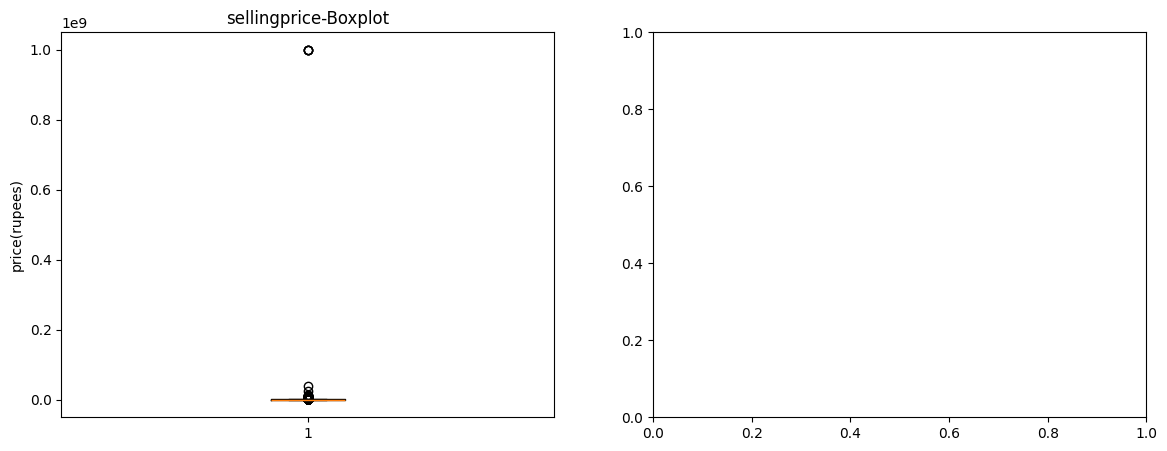

In [58]:
# visualize outliers in selling_price
import matplotlib.pyplot as plt
fig,axes=plt.subplots(1,2,figsize=(14,5))
#boxplot
axes[0].boxplot(df['selling_price'].dropna(),vert=True)
axes[0].set_title('sellingprice-Boxplot')
axes[0].set_ylabel('price(rupees)')
before=len(df)
df=df[(df['selling_price']!=9999999) & (df['selling_price']>10000) & (df['seats']>0)]
after=len(df)
print(before,after)
# You might want to add a histogram or another plot on axes[1] here, for example:
# axes[1].hist(df['selling_price'], bins=50)
# axes[1].set_title('Selling Price Distribution')
# plt.tight_layout()
# plt.show()